# This is a broker metrics related forecasting analysis for the metrics:

### query/bytes 
### query/cpu/time 
### query/node/bytes 
### query/node/time 
### query/node/ttfb 
### query/priority 
### query/time

In [11]:
from pydruid.client import *
from pydruid.utils import dimensions, filters, aggregators
import pandas as pd

In [12]:
query = PyDruid('http://test0.druidonk8s.druid.data-infra.shopee.io/', 'druid/v2')
query.set_basic_auth_credentials("admin", "s2Ysn5v5")

In [13]:
ts = query.timeseries(
    datasource='druid_cenarius_metrics_all',
    granularity='day',
    intervals='2022-01-01/2022-08-03',
    #paging_spec={'pagingIdentifies': {}, 'threshold': 1},
    #context={"timeout": 1000},
    aggregations={'maxval': aggregators.longmax('value')},
    filter=(filters.Dimension('metric') == 'query/node/bytes') & (filters.Dimension('service') == 'druid/broker')
)
df = query.export_pandas()
df['ds'] = pd.to_datetime(df['timestamp']).dt.date
df.drop(columns=['timestamp'])
df = df.rename(columns={"maxval":"y"})

In [14]:
from prophet import Prophet

m = Prophet()
m.fit(df)

15:40:59 - cmdstanpy - INFO - Chain [1] start processing
15:40:59 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = m.make_future_dataframe(periods=120)
future.tail()

,ds
131,2022-11-26
132,2022-11-27
133,2022-11-28
134,2022-11-29
135,2022-11-30


In [16]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
131,2022-11-26,1.222329e+07,1.925378e+06,2.180811e+07
132,2022-11-27,2.436824e+07,1.421241e+07,3.422323e+07
133,2022-11-28,1.765075e+07,7.445664e+06,2.713558e+07
134,2022-11-29,1.339520e+07,2.983471e+06,2.315651e+07
135,2022-11-30,2.518833e+07,1.541485e+07,3.548464e+07


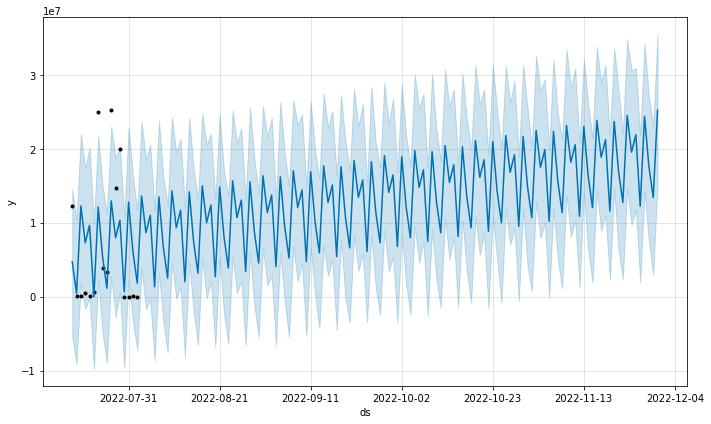

In [17]:
fig1 = m.plot(forecast)


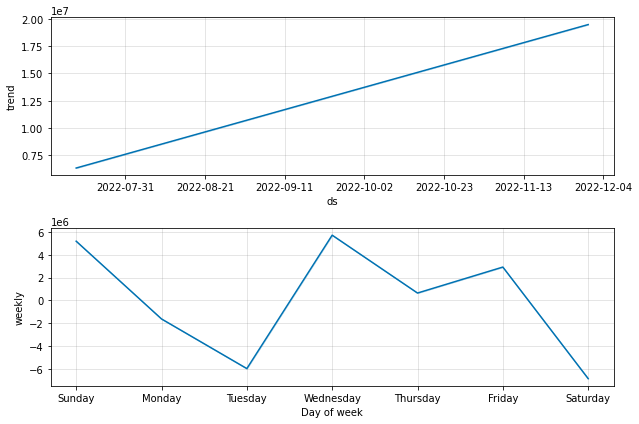

In [18]:
fig2 = m.plot_components(forecast)

In [19]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

In [20]:
plot_components_plotly(m, forecast)